# Практическая 5-6 (Саттаров Булат Рамилевич ЭФМО-01-25)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Таблица истинности

Сначала составим полный набор значений для трех логических аргументов. Для трех переменных существует $2^3 = 8$ возможных комбинаций.

In [3]:
def logical_expression(x1, x2, x3):
    return int((x1 and (not x2)) or (x2 ^ x3))

rows = []
for x1, x2, x3 in itertools.product([0, 1], repeat=3):
    rows.append({
        'x1': x1,
        'x2': x2,
        'x3': x3,
        'F': logical_expression(x1, x2, x3)
    })

truth_table = pd.DataFrame(rows)
truth_table

,x1,x2,x3,F
0,0,0,0,0
1,0,0,1,1
2,0,1,0,1
3,0,1,1,0
4,1,0,0,1
5,1,0,1,1
6,1,1,0,1
7,1,1,1,0


In [4]:
X = truth_table[['x1', 'x2', 'x3']].values.astype(np.float32)
y = truth_table[['F']].values.astype(np.float32)

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

X_t, y_t.reshape(-1)

(tensor([[0., 0., 0.],
         [0., 0., 1.],
         [0., 1., 0.],
         [0., 1., 1.],
         [1., 0., 0.],
         [1., 0., 1.],
         [1., 1., 0.],
         [1., 1., 1.]]),
 tensor([0., 1., 1., 0., 1., 1., 1., 0.]))

## Сборка нейронной сети из частей

Нейронная сеть будет собрана вручную из отдельных компонентов:

* полносвязный слой `Dense`;
* функция активации `ReLU`;
* функция активации `Sigmoid` для получения значения от 0 до 1;
* функция потерь `Binary Cross-Entropy`;
* обратное распространение ошибки для обновления весов.

Так как задача бинарная, на выходе будет один нейрон. Если значение после сигмоиды больше или равно `0.5`, считаем результатом `1`, иначе `0`.

In [5]:
class Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.5 * torch.randn(n_inputs, n_neurons)
        self.biases = torch.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs
        self.output = inputs @ self.weights + self.biases
        return self.output

    def backward(self, dvalues):
        self.dweights = self.inputs.T @ dvalues
        self.dbiases = torch.sum(dvalues, dim=0, keepdim=True)
        self.dinputs = dvalues @ self.weights.T

class ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = torch.clamp(inputs, min=0)
        return self.output

    def backward(self, dvalues):
        self.dinputs = dvalues.clone()
        self.dinputs[self.inputs <= 0] = 0

class Sigmoid:
    def forward(self, inputs):
        self.output = 1 / (1 + torch.exp(-inputs))
        return self.output

    def backward(self, dvalues):
        self.dinputs = dvalues * self.output * (1 - self.output)

class BinaryCrossentropyLoss:
    def forward(self, y_pred, y_true):
        y_pred = torch.clamp(y_pred, 1e-7, 1 - 1e-7)
        losses = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
        return torch.mean(losses)

    def backward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred = torch.clamp(y_pred, 1e-7, 1 - 1e-7)
        self.dinputs = -(y_true / y_pred - (1 - y_true) / (1 - y_pred)) / samples

## Обучение модели

Архитектура сети:

`3 аргумента → Dense(8) → ReLU → Dense(4) → ReLU → Dense(1) → Sigmoid`

Для маленькой таблицы истинности обучение выполняется сразу на всех 8 строках.

In [6]:
dense1 = Dense(3, 8)
activation1 = ReLU()
dense2 = Dense(8, 4)
activation2 = ReLU()
dense3 = Dense(4, 1)
activation3 = Sigmoid()
loss_function = BinaryCrossentropyLoss()

lr = 0.5
epochs = 10000
history = []

for epoch in range(epochs + 1):
    out = dense1.forward(X_t)
    out = activation1.forward(out)
    out = dense2.forward(out)
    out = activation2.forward(out)
    out = dense3.forward(out)
    y_pred = activation3.forward(out)

    loss = loss_function.forward(y_pred, y_t)

    if epoch % 500 == 0:
        pred_classes = (y_pred.detach().numpy() >= 0.5).astype(int)
        acc = accuracy_score(y, pred_classes)
        history.append({'epoch': epoch, 'loss': float(loss), 'accuracy': acc})

    loss_function.backward(y_pred, y_t)
    activation3.backward(loss_function.dinputs)
    dense3.backward(activation3.dinputs)
    activation2.backward(dense3.dinputs)
    dense2.backward(activation2.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    with torch.no_grad():
        dense1.weights -= lr * dense1.dweights
        dense1.biases -= lr * dense1.dbiases
        dense2.weights -= lr * dense2.dweights
        dense2.biases -= lr * dense2.dbiases
        dense3.weights -= lr * dense3.dweights
        dense3.biases -= lr * dense3.dbiases

history_df = pd.DataFrame(history)
history_df.tail()

,epoch,loss,accuracy
16,8000,0.000280,1.0
17,8500,0.000263,1.0
18,9000,0.000248,1.0
19,9500,0.000234,1.0
20,10000,0.000222,1.0


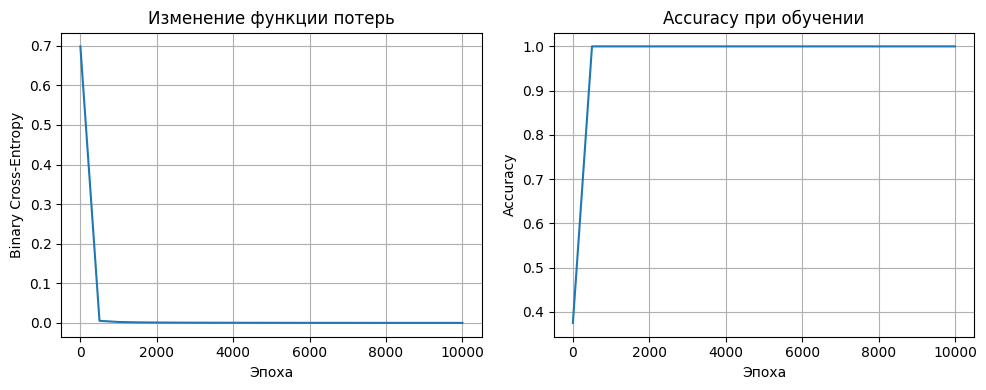

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['loss'])
plt.title('Изменение функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Binary Cross-Entropy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['accuracy'])
plt.title('Accuracy при обучении')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Проверка результата на таблице истинности

Проверим, что обученная нейронная сеть повторяет значения логического выражения для всех возможных наборов аргументов.

In [8]:
def network_forward(X_input):
    X_input = torch.tensor(X_input, dtype=torch.float32)
    out = dense1.forward(X_input)
    out = activation1.forward(out)
    out = dense2.forward(out)
    out = activation2.forward(out)
    out = dense3.forward(out)
    out = activation3.forward(out)
    return out.detach().numpy()

probabilities = network_forward(X)
predictions = (probabilities >= 0.5).astype(int)

result_table = truth_table.copy()
result_table['NN_probability'] = np.round(probabilities.reshape(-1), 4)
result_table['NN_result'] = predictions.reshape(-1)
result_table['correct'] = result_table['F'] == result_table['NN_result']

result_table

,x1,x2,x3,F,NN_probability,NN_result,correct
0,0,0,0,0,0.0017,0,True
1,0,0,1,1,1.0000,1,True
2,0,1,0,1,1.0000,1,True
3,0,1,1,0,0.0000,0,True
4,1,0,0,1,1.0000,1,True
5,1,0,1,1,1.0000,1,True
6,1,1,0,1,1.0000,1,True
7,1,1,1,0,0.0000,0,True


In [9]:
accuracy = accuracy_score(y, predictions)
matrix = confusion_matrix(y, predictions)

print('Accuracy:', accuracy)
print('Матрица путаницы:')
print(matrix)

Accuracy: 1.0
Матрица путаницы:
[[3 0]
 [0 5]]


## Функция для ввода значений аргументов

Ниже создана функция `predict_logic`, которая принимает значения `x1`, `x2`, `x3` и возвращает ответ обученной нейронной сети.

In [10]:
def predict_logic(x1, x2, x3):
    values = np.array([[x1, x2, x3]], dtype=np.float32)
    probability = network_forward(values)[0][0]
    result = int(probability >= 0.5)
    print(f'x1={x1}, x2={x2}, x3={x3}')
    print(f'Вероятность класса 1: {probability:.4f}')
    print(f'Ответ нейронной сети: {result}')
    return result

In [11]:
predict_logic(1, 0, 0)

x1=1, x2=0, x3=0
Вероятность класса 1: 1.0000
Ответ нейронной сети: 1


1

In [12]:
predict_logic(0, 1, 1)

x1=0, x2=1, x3=1
Вероятность класса 1: 0.0000
Ответ нейронной сети: 0


0

In [13]:
predict_logic(1, 1, 0)

x1=1, x2=1, x3=0
Вероятность класса 1: 1.0000
Ответ нейронной сети: 1


1

## Проверка через прямое вычисление логического выражения

Сравним ответы нейронной сети с исходным логическим выражением на всех строках таблицы истинности.

In [14]:
check_table = result_table[['x1', 'x2', 'x3', 'F', 'NN_result', 'correct']]
check_table

,x1,x2,x3,F,NN_result,correct
0,0,0,0,0,0,True
1,0,0,1,1,1,True
2,0,1,0,1,1,True
3,0,1,1,0,0,True
4,1,0,0,1,1,True
5,1,0,1,1,1,True
6,1,1,0,1,1,True
7,1,1,1,0,0,True


## Вывод

В практической работе была составлена таблица истинности для логического выражения

$$F(x_1, x_2, x_3) = (x_1 \land \neg x_2) \lor (x_2 \oplus x_3).$$

Затем из отдельных частей была собрана нейронная сеть: полносвязные слои, функции активации `ReLU` и `Sigmoid`, функция потерь `Binary Cross-Entropy` и ручное обратное распространение ошибки.

После обучения нейронная сеть правильно воспроизводит таблицу истинности. Для ввода произвольных значений аргументов реализована функция `predict_logic(x1, x2, x3)`, которая выводит вероятность и итоговый бинарный результат.